# Week 4: Ensemble Learning — Random Forest vs XGBoost

This project compares ensemble learning models for Titanic survival prediction.

The Random Forest Classifier and XGBoost Classifier are trained and compared with an earlier Logistic Regression model.

Feature importance plots are also created to understand which features are considered most important by Random Forest and XGBoost.

In [1]:
!pip install xgboost -q

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

from xgboost import XGBClassifier

In [3]:
df = pd.read_csv("train.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Create FamilySize
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Create IsAlone
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

df[['SibSp', 'Parch', 'FamilySize', 'IsAlone']].head()

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


In [5]:
# Fill missing Age values
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked values
df['Embarked'] = df['Embarked'].fillna(
    df['Embarked'].mode()[0]
)

In [6]:
X = df[
    [
        'Pclass',
        'Sex',
        'Age',
        'SibSp',
        'Parch',
        'Fare',
        'Embarked',
        'FamilySize',
        'IsAlone'
    ]
]

y = df['Survived']

In [7]:
X = pd.get_dummies(
    X,
    columns=['Sex', 'Embarked'],
    drop_first=True
)

print("Features:")
print(X.columns.tolist())

Features:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'Sex_male', 'Embarked_Q', 'Embarked_S']


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 712
Testing Samples: 179


In [9]:
logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(
    X_train,
    y_train
)

logistic_pred = logistic_model.predict(
    X_test
)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_pred
)

logistic_precision = precision_score(
    y_test,
    logistic_pred
)

logistic_recall = recall_score(
    y_test,
    logistic_pred
)

logistic_f1 = f1_score(
    y_test,
    logistic_pred
)

print("Logistic Regression Results")
print("Accuracy:", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall:", round(logistic_recall, 4))
print("F1-score:", round(logistic_f1, 4))

Logistic Regression Results
Accuracy: 0.8045
Precision: 0.7833
Recall: 0.6812
F1-score: 0.7287


In [10]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_precision = precision_score(
    y_test,
    rf_pred
)

rf_recall = recall_score(
    y_test,
    rf_pred
)

rf_f1 = f1_score(
    y_test,
    rf_pred
)

print("Random Forest Results")
print("Accuracy:", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall:", round(rf_recall, 4))
print("F1-score:", round(rf_f1, 4))

Random Forest Results
Accuracy: 0.8212
Precision: 0.7846
Recall: 0.7391
F1-score: 0.7612


In [11]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_pred = xgb_model.predict(
    X_test
)

xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

xgb_precision = precision_score(
    y_test,
    xgb_pred
)

xgb_recall = recall_score(
    y_test,
    xgb_pred
)

xgb_f1 = f1_score(
    y_test,
    xgb_pred
)

print("XGBoost Results")
print("Accuracy:", round(xgb_accuracy, 4))
print("Precision:", round(xgb_precision, 4))
print("Recall:", round(xgb_recall, 4))
print("F1-score:", round(xgb_f1, 4))

XGBoost Results
Accuracy: 0.7989
Precision: 0.7895
Recall: 0.6522
F1-score: 0.7143


In [12]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        logistic_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    'Precision': [
        logistic_precision,
        rf_precision,
        xgb_precision
    ],
    'Recall': [
        logistic_recall,
        rf_recall,
        xgb_recall
    ],
    'F1-score': [
        logistic_f1,
        rf_f1,
        xgb_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.804469,0.783333,0.681159,0.728682
1,Random Forest,0.821229,0.784615,0.739130,0.761194
2,XGBoost,0.798883,0.789474,0.652174,0.714286


In [13]:
comparison.style.format({
    'Accuracy': '{:.2%}',
    'Precision': '{:.2%}',
    'Recall': '{:.2%}',
    'F1-score': '{:.2%}'
})

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,80.45%,78.33%,68.12%,72.87%
1,Random Forest,82.12%,78.46%,73.91%,76.12%
2,XGBoost,79.89%,78.95%,65.22%,71.43%


In [14]:
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by='Importance',
    ascending=False
)

rf_importance

,Feature,Importance
4,Fare,0.268104
7,Sex_male,0.261366
1,Age,0.239298
0,Pclass,0.085326
5,FamilySize,0.047002
2,SibSp,0.026791
9,Embarked_S,0.025725
3,Parch,0.023873
6,IsAlone,0.012087
8,Embarked_Q,0.010427


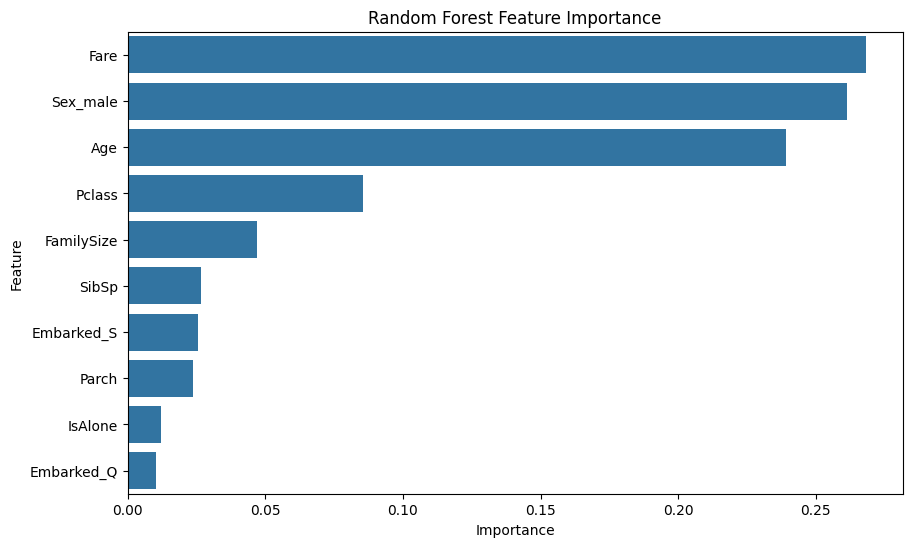

In [15]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=rf_importance,
    x='Importance',
    y='Feature'
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

In [16]:
xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by='Importance',
    ascending=False
)

xgb_importance

,Feature,Importance
7,Sex_male,0.574748
0,Pclass,0.198279
1,Age,0.046456
4,Fare,0.038650
5,FamilySize,0.036212
2,SibSp,0.035403
9,Embarked_S,0.034166
3,Parch,0.018392
8,Embarked_Q,0.017692
6,IsAlone,0.000000


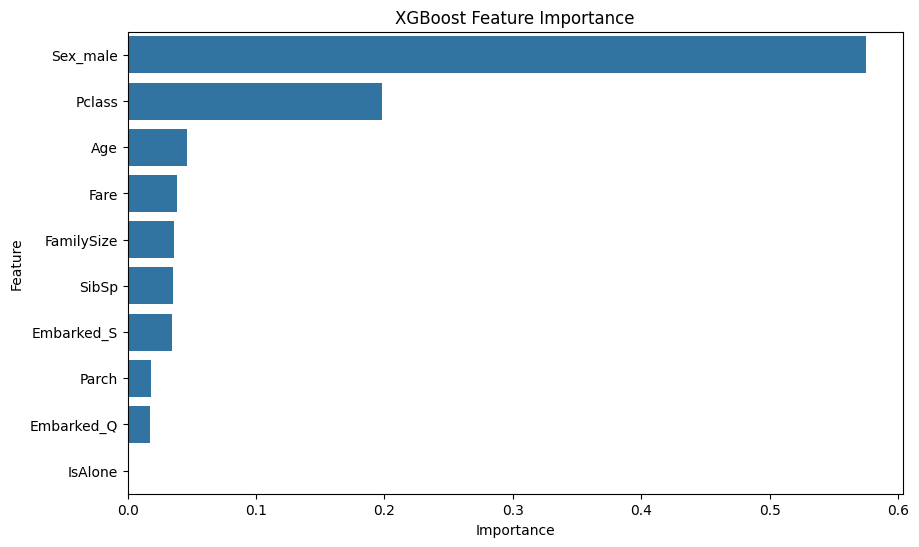

In [17]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=xgb_importance,
    x='Importance',
    y='Feature'
)

plt.title('XGBoost Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

In [18]:
print("Top 5 Random Forest Features:")
print(
    rf_importance.head(5)
)

print("\nTop 5 XGBoost Features:")
print(
    xgb_importance.head(5)
)

Top 5 Random Forest Features:
      Feature  Importance
4        Fare    0.268104
7    Sex_male    0.261366
1         Age    0.239298
0      Pclass    0.085326
5  FamilySize    0.047002

Top 5 XGBoost Features:
      Feature  Importance
7    Sex_male    0.574748
0      Pclass    0.198279
1         Age    0.046456
4        Fare    0.038650
5  FamilySize    0.036212


## Random Forest vs XGBoost

Random Forest builds many decision trees independently using random subsets of data and features, then combines their predictions through voting. This approach reduces overfitting and usually provides a stable and robust model. XGBoost builds trees sequentially, where each new tree focuses on correcting the errors made by previous trees. Because of this boosting approach, XGBoost can often achieve strong predictive performance but may require more careful tuning than Random Forest.

## Feature Importance Comparison

Random Forest and XGBoost both provide feature importance scores that help identify which features contribute most to the model's predictions.

The feature importance results from both models are compared to understand whether they identify similar or different factors as important for predicting Titanic passenger survival.

The top features identified by each model are presented in the feature importance tables and visualizations above.

## Final Conclusion

In this task, Logistic Regression, Random Forest, and XGBoost were trained and compared for Titanic passenger survival prediction. Random Forest achieved the best overall performance with an accuracy of **82.12%** and an F1-score of **76.12%**, outperforming both Logistic Regression and XGBoost on the selected evaluation metrics. The feature importance analysis showed that Random Forest considered **Fare, Sex_male, and Age** as its three most important features, while XGBoost considered **Sex_male, Pclass, and Age** as its top three features. These results demonstrate that ensemble learning can provide strong predictive performance by combining multiple decision trees, although different ensemble algorithms may assign different importance to the same features.


In [19]:
import joblib

joblib.dump(
    rf_model,
    'titanic_random_forest_model.joblib'
)

joblib.dump(
    xgb_model,
    'titanic_xgboost_model.joblib'
)

print("Models saved successfully.")

Models saved successfully.
